In [1]:
!git clone -b gsoc https://github.com/anjaliii255/Genie-Task.git
%cd Genie-Task

Cloning into 'Genie-Task'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 9 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.
/content/Genie-Task


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls /content/drive/MyDrive/ | grep -i quark

Copy of quark-gluon_data-set_n139306 (1).hdf5
quark-gluon_data-set_n139306 (1).hdf5


In [3]:
import h5py
file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'

with h5py.File(file_path, 'r') as f:
    X = f['X_jets'][:10000]  # (10000, 125, 125, 3)
    y = f['y'][:10000]

print("Loaded:", X.shape)

Loaded: (10000, 125, 125, 3)


In [4]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [6]:
file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'

with h5py.File(file_path, 'r') as f:
    X = f['X_jets'][:10000]  # (10000, 125, 125, 3)
    y = f['y'][:10000]

print("X shape:", X.shape)  # (50000, 125, 125, 3)
print("y shape:", y.shape)
print("y unique values:", np.unique(y))

X shape: (10000, 125, 125, 3)
y shape: (10000,)
y unique values: [0. 1.]


In [7]:
class JetDataset(Dataset):
    def __init__(self, X, y):
        # (N, H, W, C) -> (N, C, H, W)
        X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)

        # Normalize per sample per channel
        for i in range(X.shape[0]):
            for c in range(3):
                ch = X[i, c]
                min_val, max_val = ch.min(), ch.max()
                if max_val > min_val:
                    X[i, c] = (ch - min_val) / (max_val - min_val)

        self.X = X
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
import numpy as np
from torch.utils.data import random_split

dataset = JetDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 8000 | Val: 2000


In [9]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # (3, 125, 125) -> (32, 62, 62)
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # (32, 62, 62) -> (64, 31, 31)
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # (64, 31, 31) -> (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # (128, 16, 16) -> (256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            # (256, 8, 8) -> (128, 16, 16)
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # (128, 16, 16) -> (64, 31, 31)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # (64, 31, 31) -> (32, 62, 62)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # (32, 62, 62) -> (3, 125, 125)
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        # Force exact output size in case of off-by-one
        decoded = nn.functional.interpolate(decoded, size=(125, 125), mode='bilinear', align_corners=False)
        return decoded

model = ConvAutoencoder().to(device)

# Verify output shape before training
dummy = torch.zeros(1, 3, 125, 125).to(device)
out = model(dummy)
print("Output shape:", out.shape)  # Must be (1, 3, 125, 125)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([1, 3, 125, 125])
Total parameters: 777,987


In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

def sparse_loss(recon, original, sparsity_weight=0.5):
    mse = criterion(recon, original)
    # Penalize activations where original is near zero
    sparsity = (recon * (original < 0.01).float()).mean()
    return mse + sparsity_weight * sparsity

In [15]:
num_epochs = 10
train_losses = []
val_losses   = []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for batch_idx, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = sparse_loss(outputs, imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, imgs)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print("\nTraining complete!")

Epoch [ 1/10] | Train Loss: 0.001356 | Val Loss: 0.000252
Epoch [ 2/10] | Train Loss: 0.000455 | Val Loss: 0.000224
Epoch [ 3/10] | Train Loss: 0.000334 | Val Loss: 0.000206
Epoch [ 4/10] | Train Loss: 0.000279 | Val Loss: 0.000183
Epoch [ 5/10] | Train Loss: 0.000243 | Val Loss: 0.000166
Epoch [ 6/10] | Train Loss: 0.000221 | Val Loss: 0.000161
Epoch [ 7/10] | Train Loss: 0.000209 | Val Loss: 0.000159
Epoch [ 8/10] | Train Loss: 0.000202 | Val Loss: 0.000156
Epoch [ 9/10] | Train Loss: 0.000195 | Val Loss: 0.000152
Epoch [10/10] | Train Loss: 0.000190 | Val Loss: 0.000151

Training complete!


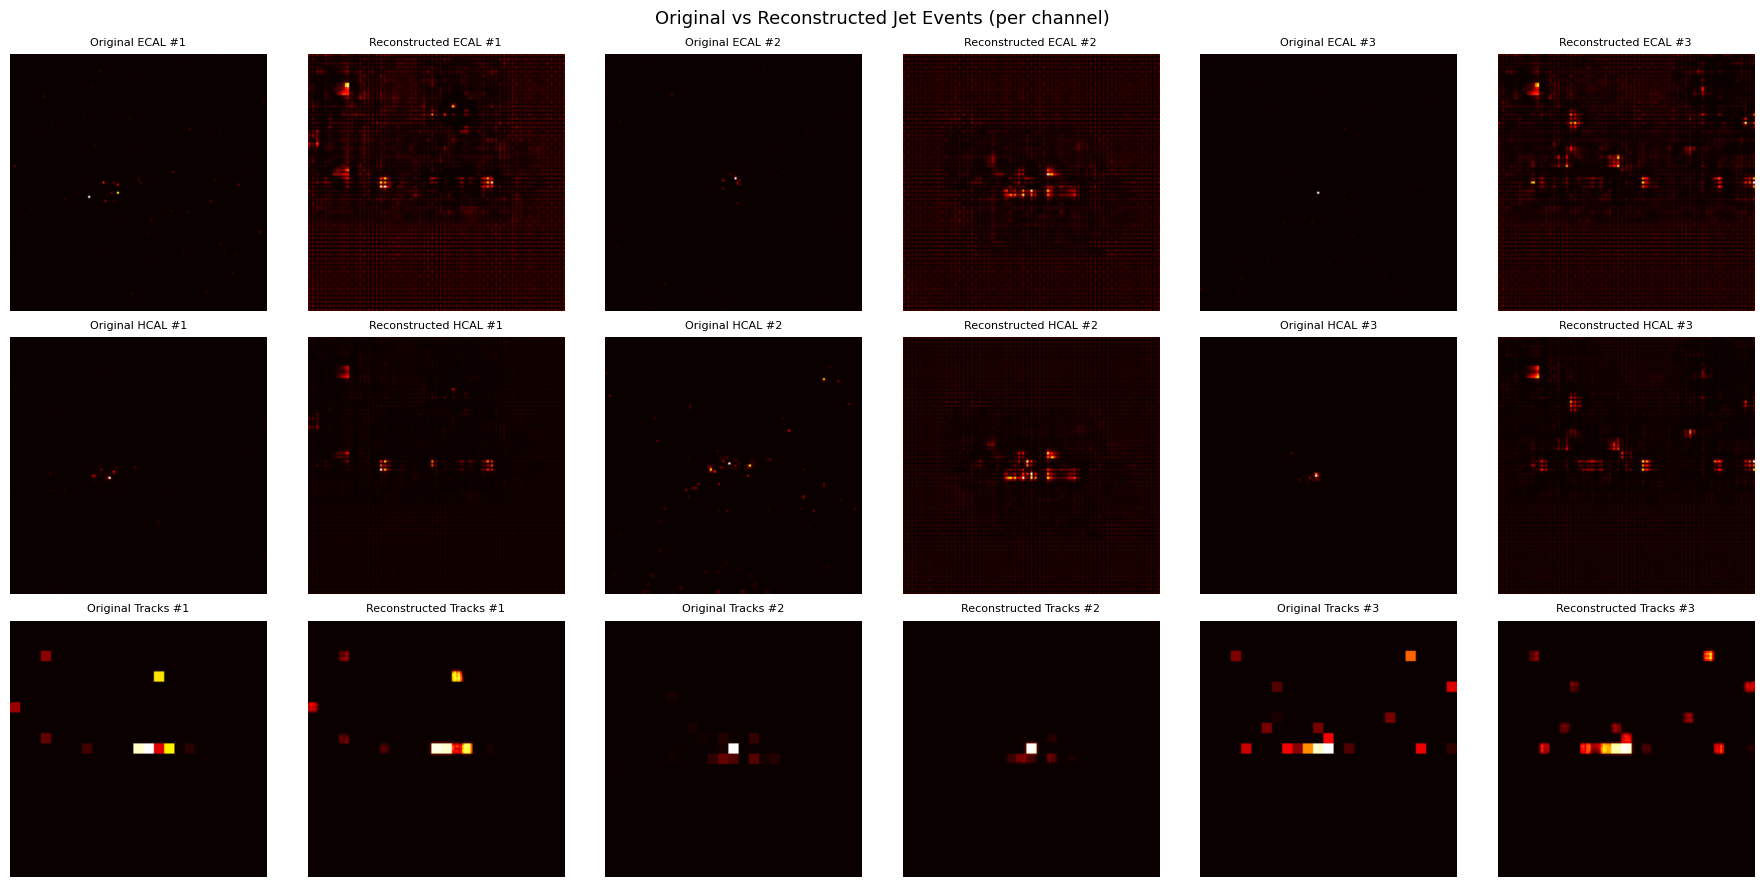

Saved comparison.png


In [16]:
model.eval()
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
channel_names = ['ECAL', 'HCAL', 'Tracks']

with torch.no_grad():
    imgs, _ = next(iter(val_loader))
    imgs = imgs.to(device)
    recons = model(imgs)
    imgs = imgs.cpu()
    recons = recons.cpu()

for row, ch_name in enumerate(channel_names):
    for col in range(3):
        # Original
        axes[row, col*2].imshow(imgs[col, row].numpy(), cmap='hot')
        axes[row, col*2].set_title(f'Original {ch_name} #{col+1}', fontsize=8)
        axes[row, col*2].axis('off')

        # Reconstructed
        axes[row, col*2+1].imshow(recons[col, row].numpy(), cmap='hot')
        axes[row, col*2+1].set_title(f'Reconstructed {ch_name} #{col+1}', fontsize=8)
        axes[row, col*2+1].axis('off')

plt.suptitle('Original vs Reconstructed Jet Events (per channel)', fontsize=13)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved comparison.png")

In [17]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

model.eval()
mse_list  = []
ssim_list = []

with torch.no_grad():
    for imgs, _ in val_loader:
        imgs = imgs.to(device)
        recons = model(imgs).cpu().numpy()
        imgs   = imgs.cpu().numpy()

        for i in range(len(imgs)):
            mse_list.append(np.mean((imgs[i] - recons[i])**2))
            # ssim expects (H, W, C)
            orig_hwc  = imgs[i].transpose(1, 2, 0)
            recon_hwc = recons[i].transpose(1, 2, 0)
            ssim_val  = ssim(orig_hwc, recon_hwc, channel_axis=2, data_range=1.0)
            ssim_list.append(ssim_val)

print(f"Mean MSE  : {np.mean(mse_list):.6f}")
print(f"Mean SSIM : {np.mean(ssim_list):.4f}")  # closer to 1.0 = better

Mean MSE  : 0.000151
Mean SSIM : 0.9783


In [20]:
torch.save(model.state_dict(), '/content/Genie-Task/common_task1_autoencoder/models/autoencoder.pth')

In [21]:
import shutil
shutil.copy('comparison.png', '/content/Genie-Task/common_task1_autoencoder/comparison.png')
print("All saved!")

All saved!


In [28]:
torch.save(model.state_dict(), '/content/Genie-Task/common_task1_autoencoder/models/autoencoder.pth')

import shutil
shutil.copy('/content/comparison.png', '/content/Genie-Task/common_task1_autoencoder/comparison.png')

print("Done!")
!ls /content/Genie-Task/common_task1_autoencoder/

Done!
comparison.png	models
